In [1]:
# -------------------- IMPORT LIBRARIES --------------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from math import sqrt

In [2]:
# -------------------- DATA LOADING --------------------
df = pd.read_csv("Salary_Data.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None

Missing Values:
YearsExperience    0
Salary             0
dtype: int64


In [3]:
# -------------------- DATA PREPROCESSING --------------------
# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Drop missing values if any
df.dropna(inplace=True)

# Features and Target
X = df[['YearsExperience']]
y = df['Salary']

In [5]:
# -------------------- TRAIN TEST SPLIT --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
# -------------------- ML PIPELINE --------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())])

In [8]:

# -------------------- MODEL TRAINING --------------------
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [9]:
# -------------------- PREDICTIONS --------------------
y_pred = pipeline.predict(X_test)

In [10]:
# -------------------- EVALUATION --------------------
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [11]:
print("\n--- Model Evaluation ---")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


--- Model Evaluation ---
MSE : 49830096.85590834
RMSE: 7059.043621901506
R2 Score: 0.9024461774180498


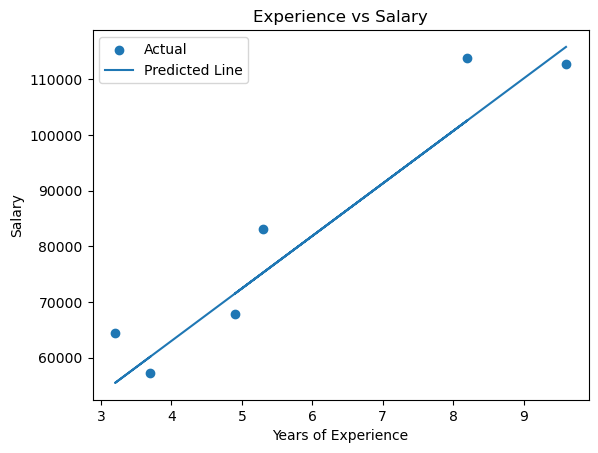

In [12]:

# -------------------- VISUALIZATION --------------------
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Predicted Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.legend()
plt.show()

In [15]:
# -------------------- USER PREDICTION --------------------
exp = float(input("Enter Years of Experience: "))

input_data = pd.DataFrame({
    'YearsExperience': [exp]
})

pred_salary = pipeline.predict(input_data)

print("Predicted Salary:", round(pred_salary[0], 2))

Enter Years of Experience:  5


Predicted Salary: 72440.66


In [16]:
# -------------------- SAVE MODEL --------------------
joblib.dump(pipeline, "salary_model.pkl")

print("\nModel saved as salary_model.pkl")


Model saved as salary_model.pkl
